In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


file_path = 'menu.csv'
menu_data = pd.read_csv(file_path)
print(menu_data.head())

    Category                              Item    Serving Size  Calories  \
0  Breakfast                      Egg McMuffin  4.8 oz (136 g)       300   
1  Breakfast                 Egg White Delight  4.8 oz (135 g)       250   
2  Breakfast                  Sausage McMuffin  3.9 oz (111 g)       370   
3  Breakfast         Sausage McMuffin with Egg  5.7 oz (161 g)       450   
4  Breakfast  Sausage McMuffin with Egg Whites  5.7 oz (161 g)       400   

   Calories from Fat  Total Fat  Total Fat (% Daily Value)  Saturated Fat  \
0                120       13.0                         20            5.0   
1                 70        8.0                         12            3.0   
2                200       23.0                         35            8.0   
3                250       28.0                         43           10.0   
4                210       23.0                         35            8.0   

   Saturated Fat (% Daily Value)  Trans Fat  ...  Carbohydrates  \
0            

In [ ]:
print(menu_data.info())
print(menu_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int

In [ ]:
numeric_data = menu_data.select_dtypes(include=['float64', 'int64'])
print(numeric_data.head())

   Calories  Calories from Fat  Total Fat  Total Fat (% Daily Value)  \
0       300                120       13.0                         20   
1       250                 70        8.0                         12   
2       370                200       23.0                         35   
3       450                250       28.0                         43   
4       400                210       23.0                         35   

   Saturated Fat  Saturated Fat (% Daily Value)  Trans Fat  Cholesterol  \
0            5.0                             25        0.0          260   
1            3.0                             15        0.0           25   
2            8.0                             42        0.0           45   
3           10.0                             52        0.0          285   
4            8.0                             42        0.0           50   

   Cholesterol (% Daily Value)  Sodium  ...  Carbohydrates  \
0                           87     750  ...           

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)  # You can choose the number of clusters
clusters = kmeans.fit_predict(scaled_data)

menu_data['Cluster'] = clusters
print(menu_data.head())

    Category                              Item    Serving Size  Calories  \
0  Breakfast                      Egg McMuffin  4.8 oz (136 g)       300   
1  Breakfast                 Egg White Delight  4.8 oz (135 g)       250   
2  Breakfast                  Sausage McMuffin  3.9 oz (111 g)       370   
3  Breakfast         Sausage McMuffin with Egg  5.7 oz (161 g)       450   
4  Breakfast  Sausage McMuffin with Egg Whites  5.7 oz (161 g)       400   

   Calories from Fat  Total Fat  Total Fat (% Daily Value)  Saturated Fat  \
0                120       13.0                         20            5.0   
1                 70        8.0                         12            3.0   
2                200       23.0                         35            8.0   
3                250       28.0                         43           10.0   
4                210       23.0                         35            8.0   

   Saturated Fat (% Daily Value)  Trans Fat  ...  \
0                           

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


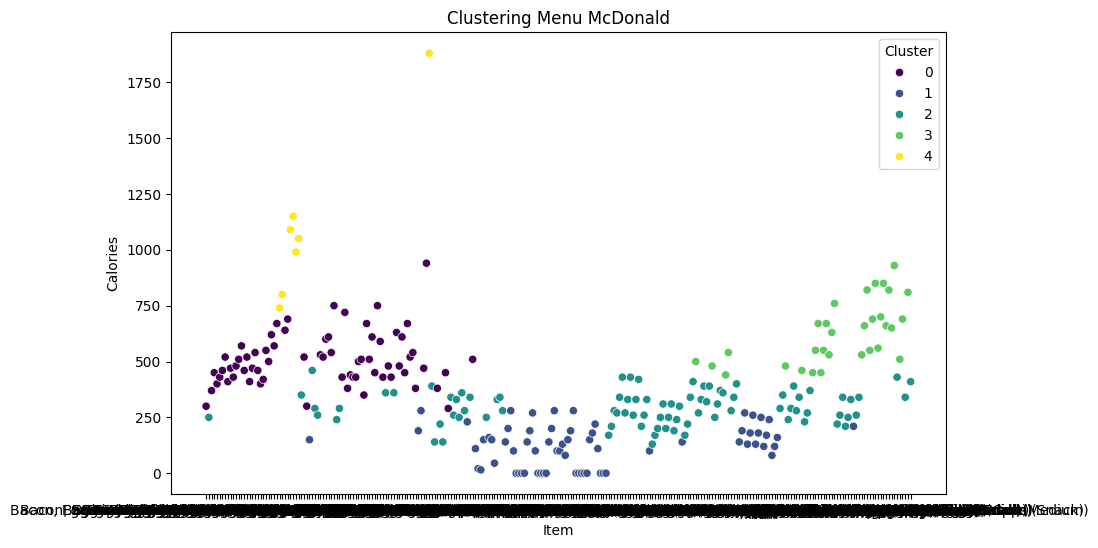

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=menu_data, x='Item', y='Calories', hue='Cluster', palette='viridis')
plt.title('Clustering Menu McDonald')
plt.xlabel('Item')
plt.ylabel('Calories')
plt.show()

In [ ]:
for i in range(5):
    print(f'Cluster {i}')
    print(menu_data[menu_data['Cluster'] == i].describe())

Cluster 0
         Calories  Calories from Fat  Total Fat  Total Fat (% Daily Value)  \
count   68.000000          68.000000  68.000000                  68.000000   
mean   507.647059         232.352941  25.823529                  39.794118   
std    117.016616          74.595779   8.382535                  12.922916   
min    290.000000          80.000000   8.000000                  13.000000   
25%    430.000000         190.000000  21.000000                  32.000000   
50%    490.000000         225.000000  25.000000                  38.500000   
75%    570.000000         280.000000  31.000000                  48.000000   
max    940.000000         530.000000  59.000000                  91.000000   

       Saturated Fat  Saturated Fat (% Daily Value)  Trans Fat  Cholesterol  \
count      68.000000                      68.000000  68.000000    68.000000   
mean        9.117647                      45.676471   0.338235   102.941176   
std         3.627340                      18.11195